In [1]:
import plotly.express as px
import polars as pl
import plotly.graph_objects as go

import chart_studio.plotly as py
import cufflinks as cf
import seaborn as sns
import plotly.express as px
%matplotlib inline

# Make Plotly work in your Jupyter Notebook
from plotly.offline import download_plotlyjs, init_notebook_mode, plot, iplot
init_notebook_mode(connected=True)
# Use Plotly locally
cf.go_offline()

pl.Config.set_tbl_width_chars(256)
pl.Config.set_fmt_str_lengths(256)
pl.Config.set_tbl_rows(24)

# Location of the IPC generated files from above.
ipc_dir = "/home/seb/git/s2protocol-rs/ipcs"

lobby_slot_init_data_df = pl.scan_ipc(f"{ipc_dir}/lobby_init_data.ipc")
details_df = pl.scan_ipc(f"{ipc_dir}/details.ipc")


# Deduplicate the lobby_slot_init_data_df:
lobby_slot_init_data_df = lobby_slot_init_data_df.unique(subset="ext_fs_sha256")

# Prepare data a bit:
details_df = (
    details_df.join(lobby_slot_init_data_df, on="ext_fs_id")
    .with_columns(
        pl.col("player_name").str.split(by="<sp/>").list.last().alias("player_name"),
    )
    .filter(
        pl.col("player_observe").eq(0)  # remove games where player is observing
        & pl.col("player_race").is_in(["Zerg", "Terran", "Protoss"])
    )
)

player_1 = "Serral"
player_2 = "Classic"
test_player = "Sazed"

def ext_fs_id_by_player_name(player_name):
    return details_df.filter(
        (pl.col("player_name").eq(player_name) & pl.col("player_observe").eq(0))
    ).select("ext_fs_id")

player_test_games = ext_fs_id_by_player_name(test_player)

details_test_games = details_df.join(player_test_games, on="ext_fs_id")

details_df.collect_schema()

Schema([('player_name', String),
        ('player_toon_region', UInt8),
        ('player_toon_program_id', UInt32),
        ('player_toon_realm', UInt32),
        ('player_toon_id', UInt64),
        ('player_race', String),
        ('player_color_a', UInt8),
        ('player_color_r', UInt8),
        ('player_color_g', UInt8),
        ('player_color_b', UInt8),
        ('player_control', UInt8),
        ('player_team_id', UInt8),
        ('player_observe', UInt8),
        ('player_result', String),
        ('player_working_set_slot_id', UInt8),
        ('player_hero', String),
        ('title', String),
        ('is_blizzard_map', Boolean),
        ('time_utc', Int64),
        ('time_local_offset', Int64),
        ('ext_fs_id', UInt64),
        ('ext_datetime', Datetime(time_unit='ns', time_zone=None)),
        ('ext_fs_sha256', String),
        ('ext_fs_file_name', String),
        ('control', Int64),
        ('user_id', Int64),
        ('team_id', Int64),
        ('observe', UInt8),


In [2]:
# Wins over time per race
wins_over_time = (
    details_df.filter(
        pl.col("player_observe").eq(0)
        & pl.col("player_result").eq("Win")
    )
    .group_by(pl.col("ext_datetime").dt.strftime("%Y-%m"), pl.col("player_race"))
    .agg(pl.len().alias("freq"))
    .collect()
)
details_df_fig = px.bar(
    wins_over_time,
    x="ext_datetime",
    color="player_race",
    y="freq",
    labels={"ext_datetime": "date"},
)
details_df_fig.show()

In [3]:
# Games vs 2 Cheater (Insane) bots races on bots: Zerg, Protoss
ai_level = "Cheater (Insane)"
typed_ai_games = (
    details_df.with_columns(pl.col("player_name").str.replace_all(r"\ *\d", "")) # Remove digits from AI names (sometimes it's 2 or 3 AIs).
        .filter(
            pl.col("player_name").str.contains(ai_level, literal=True)
            & pl.col("player_race").is_in(["Zerg", "Protoss"])
        )
    .select(pl.col("ext_fs_id"))
    .group_by(pl.col("ext_fs_id"))
    .agg(pl.len().alias("tot_ai_bots"))
    .filter(pl.col("tot_ai_bots").eq(2)) # total AI Games = 2
    .select(pl.col("ext_fs_id"))
)
# 1 v 2 Cheater (Insane) AI
three_player_games = (
    details_df
        .join(typed_ai_games, on="ext_fs_id")
        .filter(pl.col("player_observe").eq(0))
        .select(pl.col("ext_fs_id"))
        .group_by(pl.col("ext_fs_id"))
        .agg(pl.len().alias("total_players"))
        .filter(pl.col("total_players").eq(3)) # 1 v 2 AI
        .select(pl.col("ext_fs_id"))
)
vs_typed_ai_games = (
    details_df
        .join(details_test_games, on="ext_fs_id")
        .join(three_player_games, on="ext_fs_id")
)

vs_typed_ai_wins_over_time = (
    vs_typed_ai_games.filter(
        pl.col("player_name").eq(test_player) &
        pl.col("player_observe").eq(0) &
        pl.col("player_result").eq("Win")
    )
    .group_by(pl.col("ext_datetime").dt.strftime("%Y-%m"), pl.col("player_race"), pl.col("player_result"))
    .agg(pl.len().alias("freq"))
    .collect()
)
vs_type_ai_defeats_over_time = (
    vs_typed_ai_games.filter(
        pl.col("player_name").eq(test_player) &
        pl.col("player_observe").eq(0) &
        pl.col("player_result").eq("Defeat")
    )
    .group_by(pl.col("ext_datetime").dt.strftime("%Y-%m"), pl.col("player_race"), pl.col("player_result"))
    .agg(pl.len().alias("freq"))
    .with_columns(pl.col("freq").mul(-0.5).alias("freq")) # Divide by two because in each game there are two bots
    .collect()
)


fig = go.Figure()
fig.add_trace(go.Bar(x=list(vs_typed_ai_wins_over_time["ext_datetime"]), y=list(vs_typed_ai_wins_over_time["freq"]),
                marker_color='lightgreen',
                name='Wins'))
fig.add_trace(go.Bar(x=list(vs_type_ai_defeats_over_time["ext_datetime"]), y=list(vs_type_ai_defeats_over_time["freq"]),
                marker_color='crimson',
                name='Defeats'
                ))

fig.show()

In [4]:
# Games vs 2 Cheater (Insane) bot races: Terran, Protoss
ai_level = "Cheater (Insane)"
typed_ai_games = (
    details_df.with_columns(pl.col("player_name").str.replace_all(r"\ *\d", "")) # Remove digits from AI names (sometimes it's 2 or 3 AIs).
        .filter(
            pl.col("player_name").str.contains(ai_level, literal=True)
            & pl.col("player_race").is_in(["Terran", "Protoss"])
        )
    .select(pl.col("ext_fs_id"))
    .group_by(pl.col("ext_fs_id"))
    .agg(pl.len().alias("tot_ai_bots"))
    .filter(pl.col("tot_ai_bots").eq(2)) # total AI Games = 2
    .select(pl.col("ext_fs_id"))
)
# 1 v 2 Cheater (Insane) AI
three_player_games = (
    details_df
        .join(typed_ai_games, on="ext_fs_id")
        .filter(pl.col("player_observe").eq(0))
        .select(pl.col("ext_fs_id"))
        .group_by(pl.col("ext_fs_id"))
        .agg(pl.len().alias("total_players"))
        .filter(pl.col("total_players").eq(3)) # 1 v 2 AI
        .select(pl.col("ext_fs_id"))
)
vs_typed_ai_games = (
    details_df
        .join(details_test_games, on="ext_fs_id")
        .join(three_player_games, on="ext_fs_id")
)

vs_typed_ai_wins_over_time = (
    vs_typed_ai_games.filter(
        pl.col("player_name").eq(test_player) &
        pl.col("player_observe").eq(0) &
        pl.col("player_result").eq("Win")
    )
    .group_by(pl.col("ext_datetime").dt.strftime("%Y-%m"), pl.col("player_race"), pl.col("player_result"))
    .agg(pl.len().alias("freq"))
    .collect()
)
vs_type_ai_defeats_over_time = (
    vs_typed_ai_games.filter(
        pl.col("player_name").eq(test_player) &
        pl.col("player_observe").eq(0) &
        pl.col("player_result").eq("Defeat")
    )
    .group_by(pl.col("ext_datetime").dt.strftime("%Y-%m"), pl.col("player_race"), pl.col("player_result"))
    .agg(pl.len().alias("freq"))
    .with_columns(pl.col("freq").mul(-0.5).alias("freq")) # Multiplied by 0.5  because in each game there are two bots.
    .collect()
)


fig = go.Figure()
fig.add_trace(go.Bar(x=list(vs_typed_ai_wins_over_time["ext_datetime"]), y=list(vs_typed_ai_wins_over_time["freq"]),
                marker_color='lightgreen',
                name='Wins'))
fig.add_trace(go.Bar(x=list(vs_type_ai_defeats_over_time["ext_datetime"]), y=list(vs_type_ai_defeats_over_time["freq"]),
                marker_color='crimson',
                name='Defeats'
                ))

fig.show()

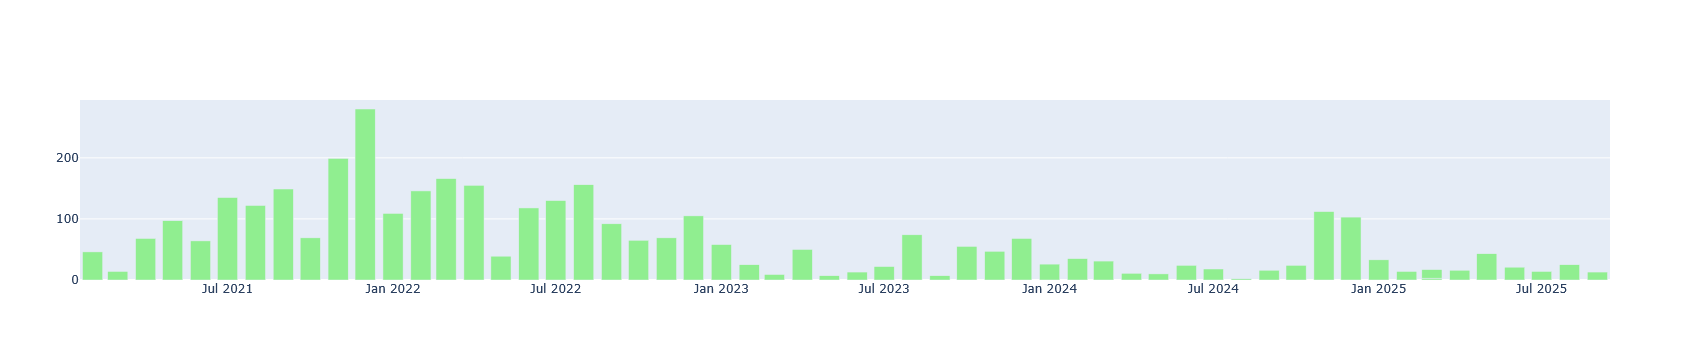

In [5]:
# Overall wins vs loss
wins_over_time = (
    details_df
        .filter(
            pl.col("player_name").eq(test_player) &
            pl.col("player_observe").eq(0) &
            pl.col("player_result").eq("Win")
        )
    .group_by(pl.col("ext_datetime").dt.strftime("%Y-%m"), pl.col("player_race"), pl.col("player_result"))
    .agg(pl.len().alias("freq"))
    .collect()
)
defeats_over_time = (
    details_df.filter(
        pl.col("player_name").eq(test_player) &
        pl.col("player_observe").eq(0) &
        pl.col("player_race").is_in(["Zerg", "Terran", "Protoss"]) &
        pl.col("player_result").eq("Defeat")
    )
    .group_by(pl.col("ext_datetime").dt.strftime("%Y-%m"), pl.col("player_race"), pl.col("player_result"))
    .agg(pl.len().alias("freq"))
    .with_columns(pl.col("freq").mul(-1).alias("freq"))
    .collect()
)


fig = go.Figure()
fig.add_trace(go.Bar(x=list(wins_over_time["ext_datetime"]), y=list(wins_over_time["freq"]),
                marker_color='lightgreen',
                name='Wins'))
fig.add_trace(go.Bar(x=list(defeats_over_time["ext_datetime"]), y=list(defeats_over_time["freq"]),
                marker_color='crimson',
                name='Defeats'
                ))

fig.show()


In [7]:
replays_over_time = (
    details_df.join(details_test_games, on="ext_fs_id")
        .with_columns(
            pl.col("player_name").str.replace_all(r"\ *\d", ""),
            pl.when(pl.col("player_result").eq("Win"))
                .then(1)
            .otherwise(-1)
            .alias("game_score")
        )
        .filter(
                (pl.col("player_name").is_in(["A.I. (Elite)", "Cheater (Insane)", "Cheater (Resources)"]))
              | pl.col("player_name").str.contains("Sazed")
        )
    .group_by(
        pl.col("player_name"),
        pl.col("ext_datetime").dt.date().alias("date"),
        pl.col("ext_datetime").dt.year().alias("year"),
    )
    .agg(pl.sum("game_score").alias("score_sum"))
    .sort([pl.col("date")])
)
replays_over_time.collect()

player_name,date,year,score_sum
str,date,i32,i32
"""Sazed""",2021-02-14,2021,-5
"""A.I. (Elite)""",2021-02-14,2021,0
"""Sazed""",2021-02-15,2021,-11
"""Sazed""",2021-02-16,2021,4
"""Sazed""",2021-02-17,2021,-2
"""Sazed""",2021-02-19,2021,4
"""Sazed""",2021-02-20,2021,4
"""Sazed""",2021-02-21,2021,0
"""Sazed""",2021-02-22,2021,5


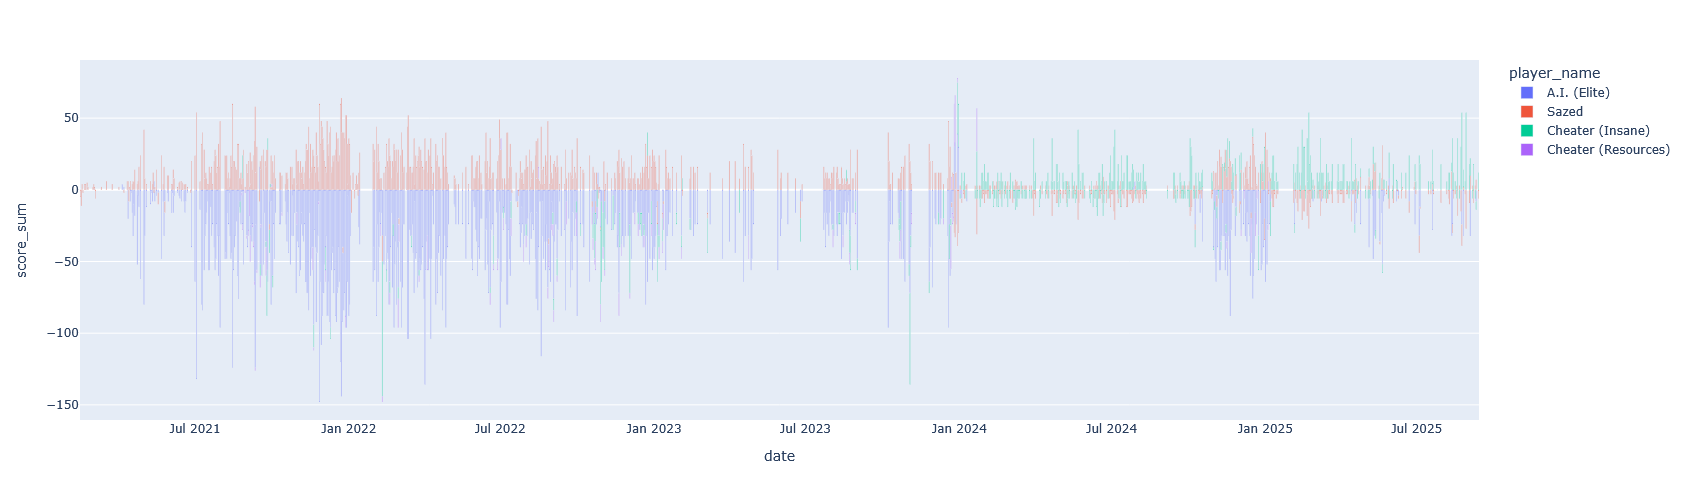

In [8]:
details_df_fig = px.bar(
    replays_over_time.collect(),
    x="date",
    y="score_sum",
    color="player_name",
    labels={"freq": "total games"},
    # trendline="ols",
    # facet_row="player_name",
    height=500,
    #color_discrete_map={"Win":"green","Defeat":"darkred"}
)
details_df_fig.show()

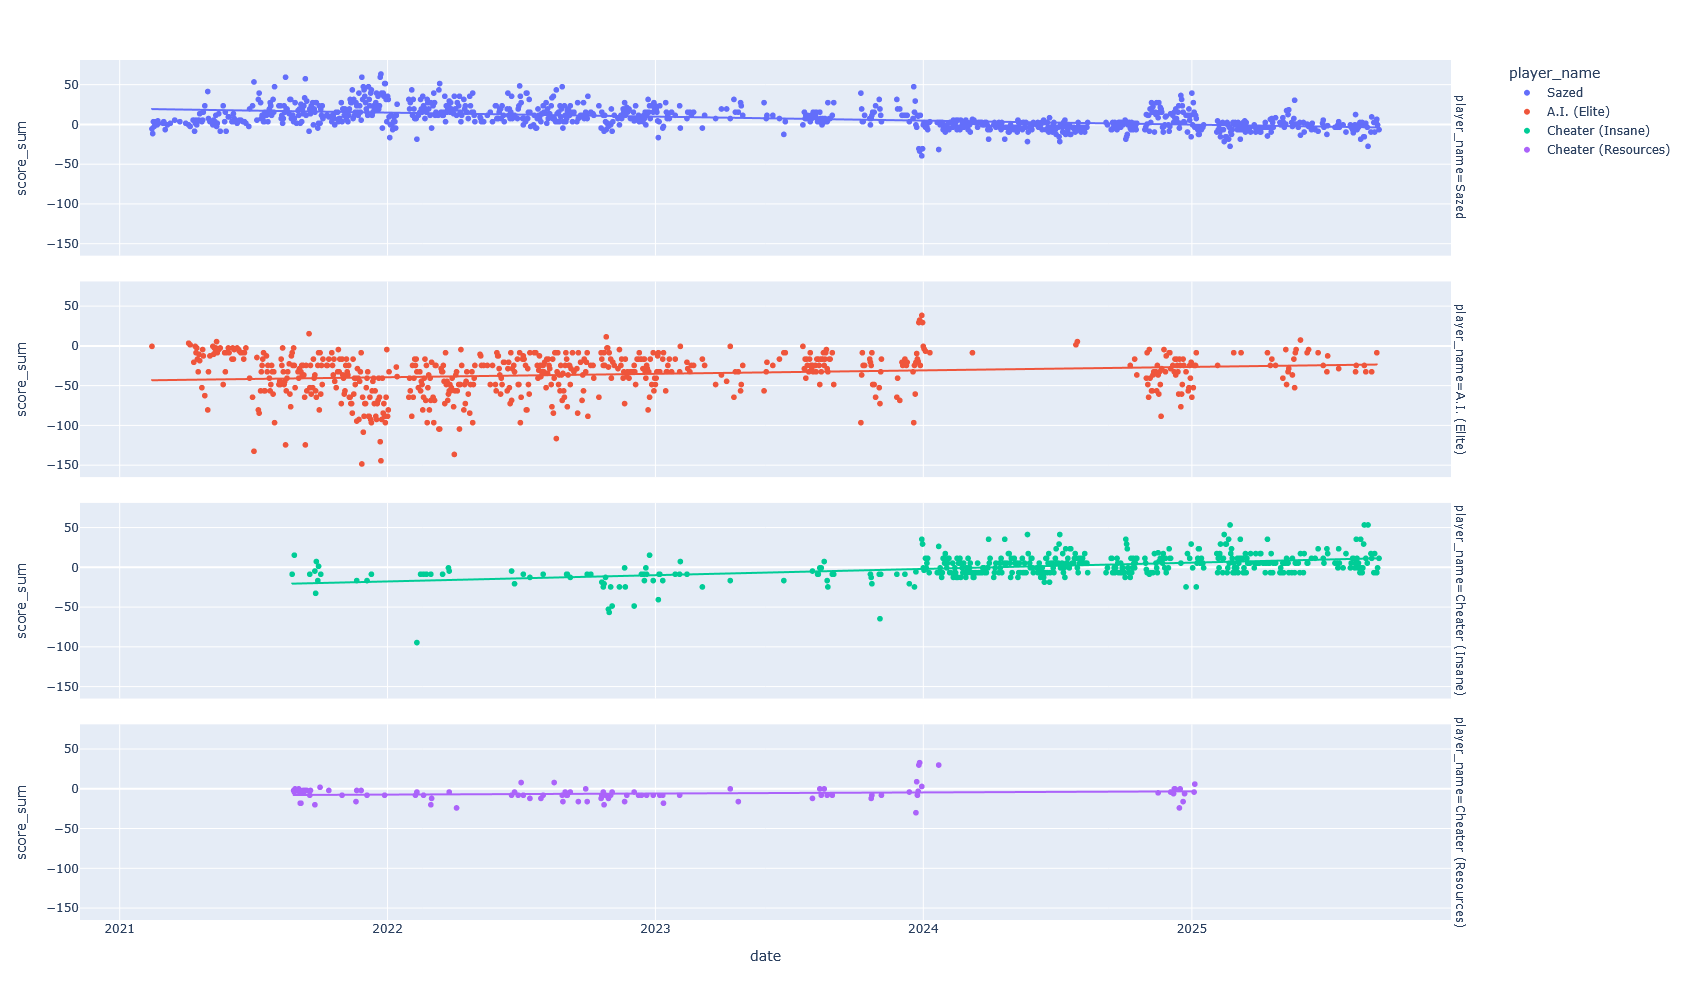

In [9]:
details_df_fig = px.scatter(
    replays_over_time.collect(),
    x="date",
    y="score_sum",
    color="player_name",
    labels={"freq": "total games"},
    facet_row="player_name",
    height=1000,
    trendline="ols",
    #color_discrete_map={"Win":"green","Defeat":"darkred"}
)
details_df_fig.show()

In [12]:
player_1_games = ext_fs_id_by_player_name(player_1)
player_2_games = ext_fs_id_by_player_name(player_2)

details_1_v_1 = details_df.join(player_1_games, on="ext_fs_id").join(
    player_2_games, on="ext_fs_id"
)

details_1_v_1.collect()

player_name,player_toon_region,player_toon_program_id,player_toon_realm,player_toon_id,player_race,player_color_a,player_color_r,player_color_g,player_color_b,player_control,player_team_id,player_observe,player_result,player_working_set_slot_id,player_hero,title,is_blizzard_map,time_utc,time_local_offset,ext_fs_id,ext_datetime,ext_fs_sha256,ext_fs_file_name,control,user_id,team_id,observe,working_set_slot_id,map_size_x,map_size_y
str,u8,u32,u32,u64,str,u8,u8,u8,u8,u8,u8,u8,str,u8,str,str,bool,i64,i64,u64,datetime[ns],str,str,i64,i64,i64,u8,u8,u8,u8
"""Serral""",2,21298,1,9691277,"""Zerg""",255,0,66,255,2,1,0,"""Win""",3,"""""","""Persephone LE""",true,133977684011304889,108000000000,16688,2025-07-23 15:20:01.130488,"""39ce2b2fd558c39a49a9175f768212e682026435fc583f3fbecbf7dbced422cc""","""/home/seb/SCReplaysOnNVMe/2025EWCReplayPack/2 - Group Stage/B8 - UB Ro4 - Classic vs Serral/20250723 - Game1 - Classic vs Serral - Persephone.SC2Replay""",2,3,1,0,3,160,184
"""Classic""",2,21298,1,9691041,"""Protoss""",255,180,20,30,2,0,0,"""Loss""",13,"""""","""Persephone LE""",true,133977684011304889,108000000000,16688,2025-07-23 15:20:01.130488,"""39ce2b2fd558c39a49a9175f768212e682026435fc583f3fbecbf7dbced422cc""","""/home/seb/SCReplaysOnNVMe/2025EWCReplayPack/2 - Group Stage/B8 - UB Ro4 - Classic vs Serral/20250723 - Game1 - Classic vs Serral - Persephone.SC2Replay""",2,3,1,0,3,160,184
"""Serral""",2,21298,1,9691277,"""Zerg""",255,0,66,255,2,1,0,"""Win""",2,"""""","""Ley Lines""",true,133977709319091000,108000000000,16689,2025-07-23 16:02:11.909100,"""fc40a873f98685ef547c41d6e41a6e5f52e1d8a110c24e380bb45e781af0f973""","""/home/seb/SCReplaysOnNVMe/2025EWCReplayPack/2 - Group Stage/B8 - UB Ro4 - Classic vs Serral/20250723 - Game3 - Classic vs Serral - Ley Lines.SC2Replay""",2,2,1,0,2,200,184
"""Classic""",2,21298,1,9691041,"""Protoss""",255,180,20,30,2,0,0,"""Loss""",13,"""""","""Ley Lines""",true,133977709319091000,108000000000,16689,2025-07-23 16:02:11.909100,"""fc40a873f98685ef547c41d6e41a6e5f52e1d8a110c24e380bb45e781af0f973""","""/home/seb/SCReplaysOnNVMe/2025EWCReplayPack/2 - Group Stage/B8 - UB Ro4 - Classic vs Serral/20250723 - Game3 - Classic vs Serral - Ley Lines.SC2Replay""",2,2,1,0,2,200,184
"""Serral""",2,21298,1,9691277,"""Zerg""",255,0,66,255,2,1,0,"""Win""",3,"""""","""Incorporeal LE""",true,133977697093163689,108000000000,16690,2025-07-23 15:41:49.316368,"""55d0bb0396c5d07ae3a901df2f8734221f43f609409a87dfecaa8d861b8440af""","""/home/seb/SCReplaysOnNVMe/2025EWCReplayPack/2 - Group Stage/B8 - UB Ro4 - Classic vs Serral/20250723 - Game2 - Classic vs Serral - Incorporeal.SC2Replay""",2,3,1,0,3,152,178
"""Classic""",2,21298,1,9691041,"""Protoss""",255,180,20,30,2,0,0,"""Loss""",4,"""""","""Incorporeal LE""",true,133977697093163689,108000000000,16690,2025-07-23 15:41:49.316368,"""55d0bb0396c5d07ae3a901df2f8734221f43f609409a87dfecaa8d861b8440af""","""/home/seb/SCReplaysOnNVMe/2025EWCReplayPack/2 - Group Stage/B8 - UB Ro4 - Classic vs Serral/20250723 - Game2 - Classic vs Serral - Incorporeal.SC2Replay""",2,3,1,0,3,152,178
"""Classic""",2,21298,1,9691041,"""Protoss""",255,0,66,255,2,1,0,"""Win""",11,"""""","""Ultralove""",true,133979357683585502,108000000000,16734,2025-07-25 13:49:28.358550,"""035622859a854c30852e566a11e0600aa1041fc7b327254146e04469362a4786""","""/home/seb/SCReplaysOnNVMe/2025EWCReplayPack/3 - Playoffs/8 - Grand Finals - Serral vs Classic/20250725 - Game3 - Classic vs Serral - Ultralove.SC2Replay""",2,2,1,0,11,184,184
"""Serral""",2,21298,1,9691277,"""Zerg""",255,180,20,30,2,0,0,"""Loss""",12,"""""","""Ultralove""",true,133979357683585502,108000000000,16734,2025-07-25 13:49:28.358550,"""035622859a854c30852e566a11e0600aa1041fc7b327254146e04469362a4786""","""/home/seb/SCReplaysOnNVMe/2025EWCReplayPack/3 - Playoffs/8 - Grand Finals - Serral vs Classic/20250725 - Game3 - Classic vs Serral - Ultralove.SC2Replay""",2,2,1,0,11,184,184
"""Serral""",2,21298,1,9691277,"""Zerg""",255,180,20,30,2,0,0,"""Win""",11,"""""","""Pylon 

In [13]:
replays_over_time = (
    details_df
        .join(details_1_v_1, on="ext_fs_id")
        .filter(pl.col("player_result").eq("Win"))
    .group_by(
        pl.col("player_name"),
        pl.col("ext_datetime").dt.date(),
        pl.col("player_result"),
    )
    .agg(pl.len().alias("freq") / 2)
    .sort([pl.col("ext_datetime")])
)
replays_over_time.collect()

player_name,ext_datetime,player_result,freq
str,date,str,f64
"""Serral""",2023-06-18,"""Win""",3.0
"""Classic""",2023-08-04,"""Win""",2.0
"""Serral""",2023-08-04,"""Win""",1.0
"""Serral""",2025-05-25,"""Win""",2.0
"""Classic""",2025-05-25,"""Win""",3.0
"""Serral""",2025-07-23,"""Win""",3.0
"""Serral""",2025-07-25,"""Win""",5.0
"""Classic""",2025-07-25,"""Win""",2.0


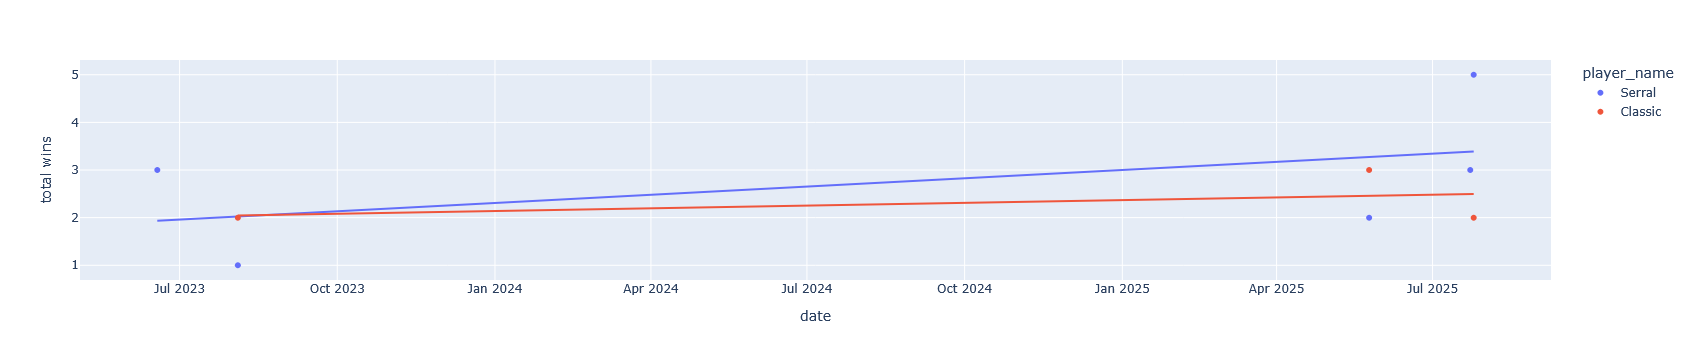

In [11]:
details_df_fig = px.scatter(
    replays_over_time.collect(),
    y="freq",
    x="ext_datetime",
    color="player_name",
    labels={"ext_datetime": "date", "freq": "total wins"},
    trendline="ols",
    # markers=True,
    #color_discrete_map={"Win":"green","Defeat":"darkred"}
)
details_df_fig.show()